# EDA 02 — Validação e mineração de indicadores

**Projeto:** canavis — benchmarking regional da cana-de-açúcar na Paraíba  
**Usuário final:** Ricardo, gerente agrícola (decisões estruturais de longo prazo)

Cada indicador — os cinco herdados da proposta inicial e os cinco candidatos minerados — passa por uma ficha de cinco campos: fórmula, exemplo com dado real, validação estatística, leitura de UX e regra de agregação. No fim, um veredito honesto: **mantém**, **ajusta** ou **descarta**.

O princípio é o da disciplina: descartar com evidência vale tanto quanto manter. Um indicador que não discrimina, que é redundante com outro ou que engana na agregação não entra no produto por mais que pareça sofisticado.

As funções vêm do pacote (`canavis.domain`, `canavis.validation`); o notebook só as exercita sobre os dados reais.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from canavis import storage
from canavis.config import load_settings
from canavis.domain import indicators, features

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

Q, A = "Quantidade produzida", "Área colhida"
interim = load_settings().paths.interim
pam = storage.read(interim, "ibge_pam")


def base_larga(extracao):
    sub = pam[pam["extracao"] == extracao]
    w = sub.pivot_table(index=["local", "periodo"], columns="variavel", values="valor").reset_index()
    w.columns.name = None
    w["produtividade"] = indicators.produtividade(w[Q], w[A])
    return w


uf = base_larga("serie_ufs_brasil")
micro = base_larga("serie_microrregioes_pb")
uf23 = uf[uf["periodo"] == 2023].dropna(subset=[Q, A]).copy()
print(f"UFs em 2023: {len(uf23)} | microrregiões-ano: {len(micro)}")

UFs em 2023: 27 | microrregiões-ano: 307


## Parte A — Auditoria dos indicadores herdados

### A.1 Produtividade (t/ha)

| Campo | Conteúdo |
|-------|----------|
| **Fórmula** | quantidade produzida (t) ÷ área colhida (ha) |
| **Exemplo** | ver célula abaixo (PB 2023) |
| **Estatística** | CV entre UFs mede discriminação |
| **UX** | número que o Ricardo já conhece; leitura direta |
| **Agregação** | **não é aditivo**: recalcular como soma/soma, nunca média de médias |

In [2]:
from canavis.validation.series import coeficiente_variacao

cv_prod = coeficiente_variacao(uf23["produtividade"])
media_simples = uf23["produtividade"].mean()
prod_agregada = uf23[Q].sum() / uf23[A].sum()

print(f"CV entre UFs: {cv_prod:.1%}  (discrimina bem)")
print(f"Média simples das produtividades: {media_simples:.1f} t/ha")
print(f"Produtividade do agregado (soma/soma): {prod_agregada:.1f} t/ha")
print(f"Erro de agregar errado: {abs(media_simples - prod_agregada) / prod_agregada:.1%}")
print("\nVEREDITO: MANTÉM — com regra de agregação soma/soma obrigatória.")

CV entre UFs: 31.9%  (discrimina bem)
Média simples das produtividades: 61.1 t/ha
Produtividade do agregado (soma/soma): 77.9 t/ha
Erro de agregar errado: 21.5%

VEREDITO: MANTÉM — com regra de agregação soma/soma obrigatória.


A diferença acima é a armadilha mais comum de dashboard: somar ou promediar rendimento médio dá um número errado. Na Etapa 2, a medida de produtividade tem que ser `SUM(quantidade) / SUM(area)`, não `AVERAGE(rendimento)`.

### A.2 Participação regional · A.3 Desvio vs referência · A.4 Variação safra a safra

In [3]:
# Participação
total = uf23[Q].sum()
uf23["participacao"] = indicators.participacao_regional(uf23[Q], total)
print(f"A.2 PARTICIPAÇÃO: soma = {uf23['participacao'].sum():.1f}%  | VEREDITO: MANTÉM")

# Desvio vs referencia — testar redundancia com produtividade
uf23["desvio"] = indicators.desvio_vs_referencia(uf23["produtividade"], uf23["produtividade"].mean())
corr = uf23[["produtividade", "desvio"]].corr().iloc[0, 1]
print(f"A.3 DESVIO: corr com produtividade = {corr:.3f}  | VEREDITO: não é card autônomo, é forma de exibir produtividade")

# Variacao safra a safra na PB
pb = uf[uf["local"] == "Paraíba"].sort_values("periodo").copy()
pb["variacao"] = indicators.variacao_periodo(pb["produtividade"])
print(f"A.4 VARIAÇÃO: |var| média = {pb['variacao'].abs().mean():.1f}%, CV = {coeficiente_variacao(pb['variacao']):.0%}  | VEREDITO: AJUSTA (leitura pontual, não tendência)")

A.2 PARTICIPAÇÃO: soma = 100.0%  | VEREDITO: MANTÉM
A.3 DESVIO: corr com produtividade = 1.000  | VEREDITO: não é card autônomo, é forma de exibir produtividade
A.4 VARIAÇÃO: |var| média = 5.9%, CV = 709%  | VEREDITO: AJUSTA (leitura pontual, não tendência)


## Parte B — Mineração das features de longo prazo

Calculadas por microrregião, na janela recente (2014–2023), como decidido no ADR de granularidade. O teste central é duplo: cada feature **discrimina** entre regiões, e não é **redundante** com as outras.

In [4]:
recente = micro[micro["periodo"] >= 2014]

# volatilidade é calculada aqui apenas para demonstrar a redundância que motivou
# seu descarte; por isso usamos coeficiente_variacao direto, não uma função do domínio.
linhas = []
for nome, grp in recente.groupby("local"):
    grp = grp.sort_values("periodo")
    if grp["produtividade"].notna().sum() < 5:
        continue
    linhas.append({
        "microrregiao": nome,
        "tendencia": features.tendencia_anual(grp["periodo"], grp["produtividade"]),
        "volatilidade": coeficiente_variacao(grp["produtividade"]),
        "resiliencia": features.resiliencia_climatica(grp["produtividade"]),
        "elasticidade": features.elasticidade_area_produtividade(grp[A], grp["produtividade"]),
    })

feat = pd.DataFrame(linhas)
print(f"Microrregiões com série suficiente: {len(feat)}")
feat.round(3)

Microrregiões com série suficiente: 15


,microrregiao,tendencia,volatilidade,resiliencia,elasticidade
0,Brejo Paraibano - PB,1.778,0.118,0.883,-0.420
1,Cajazeiras - PB,1.360,0.137,0.753,-0.788
2,Cariri Ocidental - PB,2.037,0.209,0.882,0.951
3,Curimataú Oriental - PB,0.242,0.051,1.000,0.417
4,Guarabira - PB,1.030,0.087,0.928,0.091
5,Itabaiana - PB,-0.081,0.067,0.915,0.557
6,Itaporanga - PB,0.123,0.073,0.948,0.132
7,João Pessoa - PB,0.543,0.057,0.993,-0.054
8,Litoral Norte - PB,0.791,0.070,0.943,0.767
9,Litoral Sul - PB,-0.319,0.062,0.917,0.595


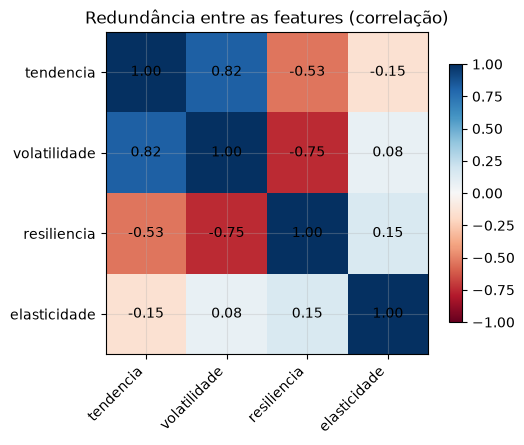

In [5]:
matriz = feat[["tendencia", "volatilidade", "resiliencia", "elasticidade"]].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(matriz, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(matriz)))
ax.set_yticks(range(len(matriz)))
ax.set_xticklabels(matriz.columns, rotation=45, ha="right")
ax.set_yticklabels(matriz.columns)
for i in range(len(matriz)):
    for j in range(len(matriz)):
        ax.text(j, i, f"{matriz.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title("Redundância entre as features (correlação)")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

**Leitura da matriz:**

- **Volatilidade × Resiliência ≈ −0,75:** medem o mesmo eixo de risco por lados opostos. Manter só uma. Escolhemos **resiliência**, porque "aguenta a seca" é mais interpretável para o Ricardo que um coeficiente de variação.
- **Tendência × Volatilidade ≈ 0,82:** correlacionadas, mas não idênticas; lê-se juntas (região que cresce rápido tende a oscilar mais).
- **Elasticidade:** quase não se correlaciona com as demais — traz informação nova. É a que mais agrega.

**Vereditos da Parte B:** tendência = MANTÉM; resiliência = MANTÉM; volatilidade = DESCARTA (redundante com resiliência); elasticidade = MANTÉM.

### B.5 Intensidade industrial (CONAB × cana)

Cruzamento da produção de açúcar com a de cana. O teste é se serve como série temporal ou apenas como perfil da UF.

In [6]:
conab = storage.read(interim, "conab_cana")
conab["intensidade"] = features.intensidade_industrial(conab["producao_acucar_mil_t"], conab["producao_mil_t"])

pb_conab = conab[conab["uf"] == "PB"]["intensidade"].dropna()
atr_pb = conab[conab["uf"] == "PB"]["produtcao_atr_kg_t"].dropna()
print(f"Intensidade açúcar/cana PB — CV temporal: {pb_conab.std() / pb_conab.mean():.0%}  (ruidosa: reflete decisão comercial)")
print(f"ATR publicado PB — CV temporal: {atr_pb.std() / atr_pb.mean():.0%}  (estável: qualidade da matéria-prima)")
print("\nVEREDITO: ATR da CONAB para qualidade; intensidade açúcar/cana só para perfil de destino da UF, não como série.")

Intensidade açúcar/cana PB — CV temporal: 26%  (ruidosa: reflete decisão comercial)
ATR publicado PB — CV temporal: 6%  (estável: qualidade da matéria-prima)

VEREDITO: ATR da CONAB para qualidade; intensidade açúcar/cana só para perfil de destino da UF, não como série.


## Quadro-resumo dos vereditos

| Indicador | Origem | Veredito | Motivo |
|-----------|--------|----------|--------|
| Produtividade | herdado | **mantém** | discrimina (CV 32%); exige agregação soma/soma |
| Participação regional | herdado | **mantém** | mostra concentração real |
| Desvio vs referência | herdado | **rebaixa** | redundante com produtividade (r=1,0); vira forma de exibição |
| Variação safra a safra | herdado | **ajusta** | ruidosa; leitura pontual, não tendência |
| Mix açúcar/etanol | herdado | **mantém** | decisão estratégica citada pela persona |
| Tendência de produtividade | minerado | **mantém** | discrimina; usar janela recente |
| Resiliência climática | minerado | **mantém** | eixo de risco interpretável |
| Volatilidade | minerado | **descarta** | redundante com resiliência (r=−0,75) |
| Elasticidade área×produtividade | minerado | **mantém** | informação independente |
| Intensidade industrial | minerado | **ajusta** | perfil de UF sim, série não; ATR é melhor para qualidade |

Este quadro alimenta o ADR de vereditos e define o conjunto de medidas que a Etapa 2 vai implementar.